In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData

In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
data = LoadBaseSatelliteData(201601, region="BRAZIL", load_everything=True, verbose=True)
ds = data.met_file

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201601*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 1438 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201601*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


In [7]:
#ds.load()
wind_ds = ds[['x_wind', 'y_wind','upward_air_velocity']].load()

In [ ]:
data = LoadBaseSatelliteData(2016, region="BRAZIL",freq=100, load_everything=True, verbose=True)
ds = data.met_file
full_wind_ds = ds[['x_wind', 'y_wind']].load()
full_wind_ds.to_netcdf('wind_data_2016.nc')

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
reduced the number of datapoints by frequency 20
Loading 1084 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


In [10]:
ds = data.met_file

In [11]:
ds

<xarray.Dataset>
Dimensions:                              (lat: 357, levels: 20, lon: 239,
                                          time: 744)
Coordinates:
  * lat                                  (lat) float64 -60.98 -60.75 ... 22.32
    sigma                                (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * levels                               (levels) int32 1 3 6 9 ... 48 51 54 57
    level_height                         (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * lon                                  (lon) float64 -91.33 -90.98 ... -7.553
  * time                                 (time) datetime64[ns] 2016-01-01 ......
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

In [35]:
wind_ds = ds[['x_wind', 'y_wind']].load()

In [36]:
wind_ds.to_netcdf('wind_data_201601.nc')

In [17]:
# 1. Select the level you want (e.g., level 0) and drop the time dimension by averaging
# This creates a "recipe" for the mean
mean_ds = ds.isel(levels=0).mean(dim='time')
# 2. TRIGGER THE LOAD
# This is the "heavy lifting" step. Once this finishes, everything is in RAM.
mean_ds.load()

<xarray.Dataset>
Dimensions:                              (lat: 357, lon: 239)
Coordinates:
  * lat                                  (lat) float64 -60.98 -60.75 ... 22.32
    sigma                                float32 0.9977
    levels                               int32 1
    level_height                         float32 20.0
  * lon                                  (lon) float64 -91.33 -90.98 ... -7.553
Data variables:
    air_pressure                         (lat, lon) float32 9.939e+04 ... 9.7...
    air_pressure_at_sea_level            (lat, lon) float32 9.963e+04 ... 1.0...
    air_temperature                      (lat, lon) float32 276.4 ... 293.7
    atmosphere_boundary_layer_thickness  (lat, lon) float32 447.5 ... 521.0
    surface_air_pressure                 (lat, lon) float32 9.963e+04 ... 9.8...
    surface_upward_sensible_heat_flux    (lat, lon) float32 2.316 ... 26.97
    upward_air_velocity                  (lat, lon) float32 3.279e-06 ... 0.0...
    x_wind                               (lat, lon) float32 5.974 ... -5.314
    y_wind                               (lat, lon) float32 -0.5055 ... -1.303

In [20]:
mean_wind_ds = mean_ds[['x_wind', 'y_wind']]

In [22]:
mean_wind_ds.to_netcdf('mean_wind_data.nc')

# Velocity wind

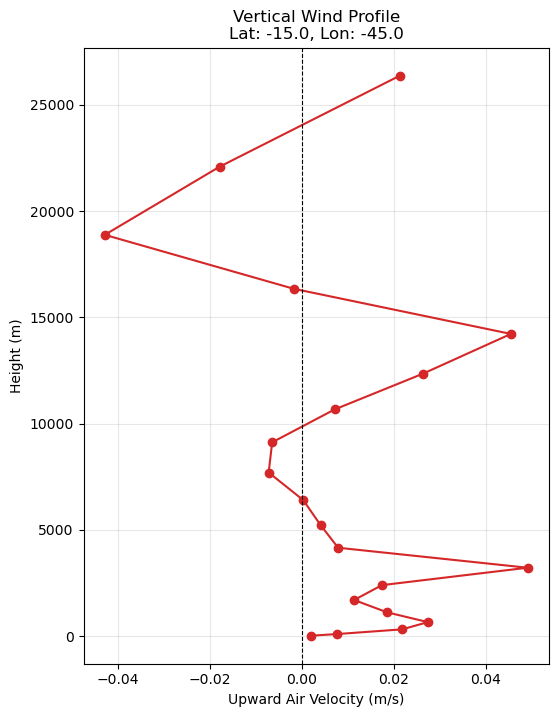

In [10]:
def plot_vertical_velocity_profile(ds, lat_val, lon_val, time_idx=0):
    # Nawid - function currently for a single location, and a particular time, do we want seasonally, or average over different locations
    # Select point and time
    wind_info = ds.sel(lat=lat_val, lon=lon_val, method='nearest').isel(time=time_idx)
    
    plt.figure(figsize=(6, 8))
    # Nawid - wind as upward win as function of height
    plt.plot(wind_info['upward_air_velocity'], wind_info['level_height'], marker='o', color='tab:red')
    
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8) # Zero line
    plt.xlabel('Upward Air Velocity (m/s)')
    plt.ylabel('Height (m)')
    plt.title(f'Vertical Wind Profile\nLat: {lat_val}, Lon: {lon_val}')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_vertical_velocity_profile(wind_ds,lat_val=-15.0, lon_val=-45.0,time_idx=0)

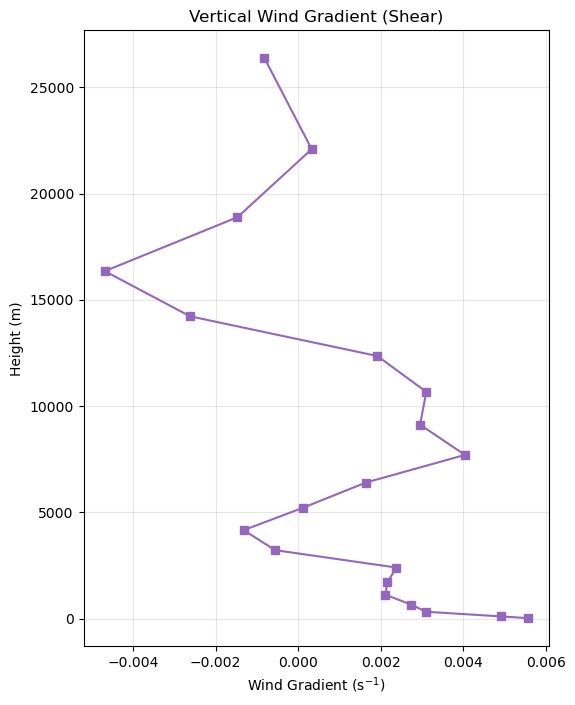

In [ ]:
def plot_wind_gradient(ds, lat_val, lon_val, time_idx=0):
    # Nawid - plots wiind gradient of the horizontal wind at a particualr location as a funciton of height
    # 1. Select data
    subset = ds.sel(lat=lat_val, lon=lon_val, method='nearest').isel(time=time_idx)
    
    # 2. Calculate horizontal wind speed
    speed = np.sqrt(subset['x_wind']**2 + subset['y_wind']**2)
    
    # 3. Calculate Gradient (dU/dZ)
    # np.gradient handles the spacing between level_heights automatically
    # Nawid - calculates 
    shear = np.gradient(speed, subset['level_height'])
    
    fig, ax = plt.subplots(figsize=(6, 8))
    ax.plot(shear, subset['level_height'], marker='s', color='tab:purple', label='dU/dZ')
    
    ax.set_xlabel('Wind Gradient (s$^{-1}$)')
    ax.set_ylabel('Height (m)')
    ax.set_title('Wind Gradient')
    ax.grid(True, alpha=0.3)
    plt.show()

plot_wind_gradient(wind_ds,lat_val=-15.0, lon_val=-45.0,time_idx=0)

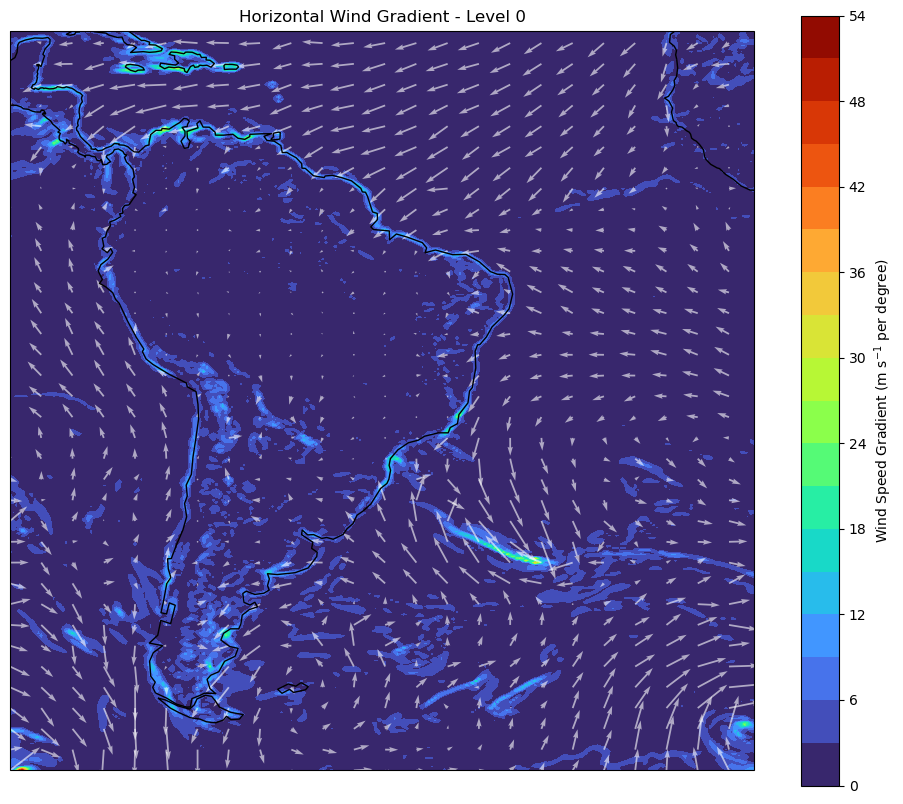

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_horizontal_wind_gradient(ds, level_idx=0, time_idx=0):
    '''
    Nawid - We get the wind data at a particular time at a particular level and then see how the gradient changs as we change the the lattitude and the longitude
    '''
    # 1. Select a slice of data
    subset = ds.isel(levels=level_idx, time=time_idx)
    
    # 2. Calculate Wind Speed Magnitude
    speed = np.sqrt(subset['x_wind']**2 + subset['y_wind']**2)
    
    # 3. Calculate Spatial Gradients (dU/dx and dU/dy)
    # This gives us the rate of change of speed per degree of lat/lon
    grad_y, grad_x = np.gradient(speed, subset.lat, subset.lon)
    
    # Calculate the Magnitude of the Gradient (Total Horizontal Shear)
    grad_magnitude = np.sqrt(grad_y**2 + grad_x**2)

    # 4. Plotting
    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()

    # Plot the gradient magnitude as a filled contour
    im = ax.contourf(subset.lon, subset.lat, grad_magnitude, 
                     levels=20, cmap='turbo', transform=ccrs.PlateCarree())
    
    # Overlay quivers to show wind direction for context
    skip = (slice(None, None, 10), slice(None, None, 10))
    ax.quiver(subset.lon[skip[1]], subset.lat[skip[0]], 
              subset['x_wind'][skip], subset['y_wind'][skip], 
              color='white', alpha=0.6, transform=ccrs.PlateCarree())
    
    plt.colorbar(im, label='Wind Speed Gradient (m s$^{-1}$ per degree)')
    plt.title(f"Horizontal Wind Gradient - Level {level_idx}")
    plt.show()

plot_horizontal_wind_gradient(wind_ds,time_idx=0)

## Quiver map using u and v

In [28]:
ds = xr.open_dataset('wind_data_2016.nc')
ds_subsampled = ds[['x_wind', 'y_wind']].isel(time=slice(None, None, 20))

# 2. Select your vertical level (e.g., the first level)
# This is critical because loading 20 levels of 876 time steps is still quite heavy
ds_ready = ds_subsampled.isel(levels=0)

# 3. Load the data into memory
# Since we narrowed it down first, this will be much faster
ds_ready.load()

# 4. Access your variables for plotting
u = ds_ready['x_wind']
v = ds_ready['y_wind']

# Access your pre-averaged variables
#u = ds_lite['x_wind'].isel(levels=0)
#v = ds_lite['y_wind'].isel(levels=0)

In [23]:
u = wind_ds['x_wind'].isel(levels=0)
v = wind_ds['y_wind'].isel(levels=0)

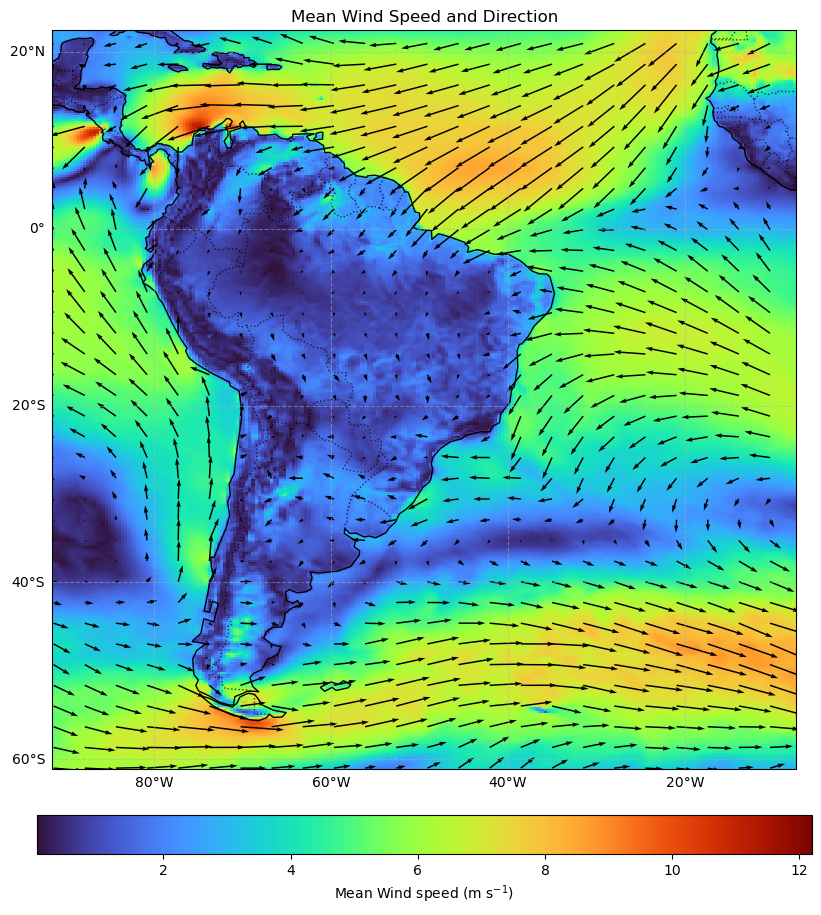

In [26]:
def quiver_map(u, v):
    # 1. Compute the time mean
    # Since your data is (lat, lon, time), mean("time") 
    # results in a (lat, lon) 2D array.
    # Nawid - get the meaan u and mean v across time
    u_mean = u.mean("time")
    v_mean = v.mean("time")
    
    # Nawid - cacculate the mean speeds
    # 2. Calculate wind speed from the mean components
    wind_speed = np.sqrt(u_mean**2 + v_mean**2)

    # 3. Setup the Map
    fig = plt.figure(figsize=(10, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # 4. Plot the Background Speed
    # We specify x and y coordinates explicitly to avoid dimension confusion
    im = wind_speed.plot(
        ax=ax, 
        x='lon', y='lat',  # Explicitly tell xarray which dim is which
        transform=ccrs.PlateCarree(),
        cmap='turbo',
        add_colorbar=True,
        cbar_kwargs={'label': 'Mean Wind speed (m s$^{-1}$)', 'orientation': 'horizontal', 'pad': 0.05}
    )

    # 5. Plot the Quiver (Arrows)
    # We use every 10th point to avoid a "black blob"
    skip = 10
    
    # Extract coordinate values and data values for the skip
    lons = u_mean.lon[::skip]
    lats = u_mean.lat[::skip]
    u_vals = u_mean.values[::skip, ::skip]
    v_vals = v_mean.values[::skip, ::skip]

    q = ax.quiver(
        lons, lats, u_vals, v_vals,
        transform=ccrs.PlateCarree(),
        color='black',
        scale=150,
        width=0.002 # Makes the arrow stems thinner and cleaner
    )

    # 6. Map Aesthetics
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    plt.title('Mean Wind Speed and Direction')
    plt.show()

# Run the function
quiver_map(u, v)

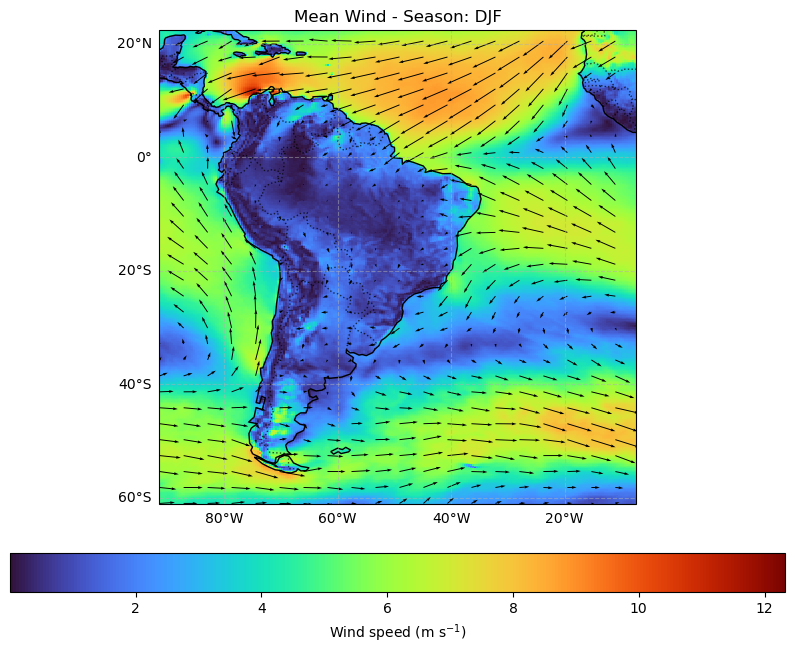

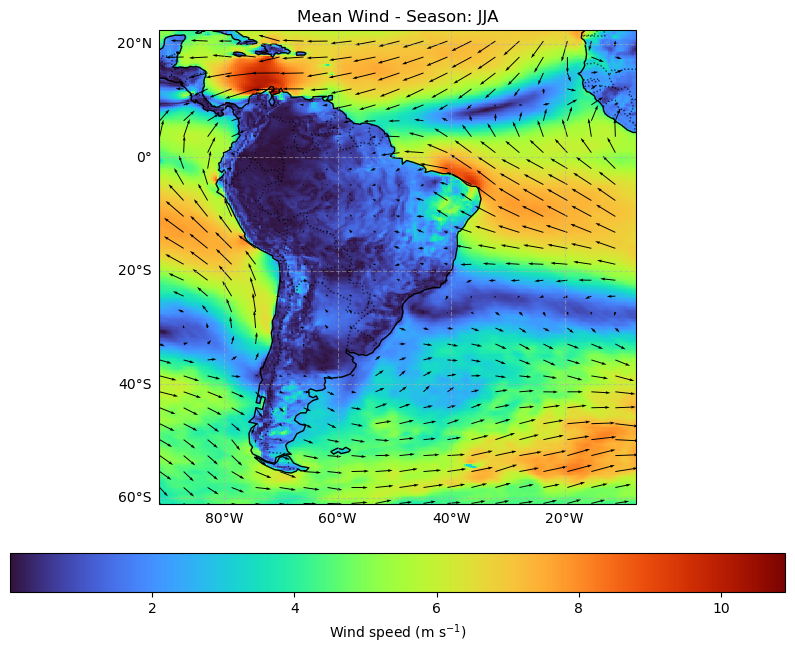

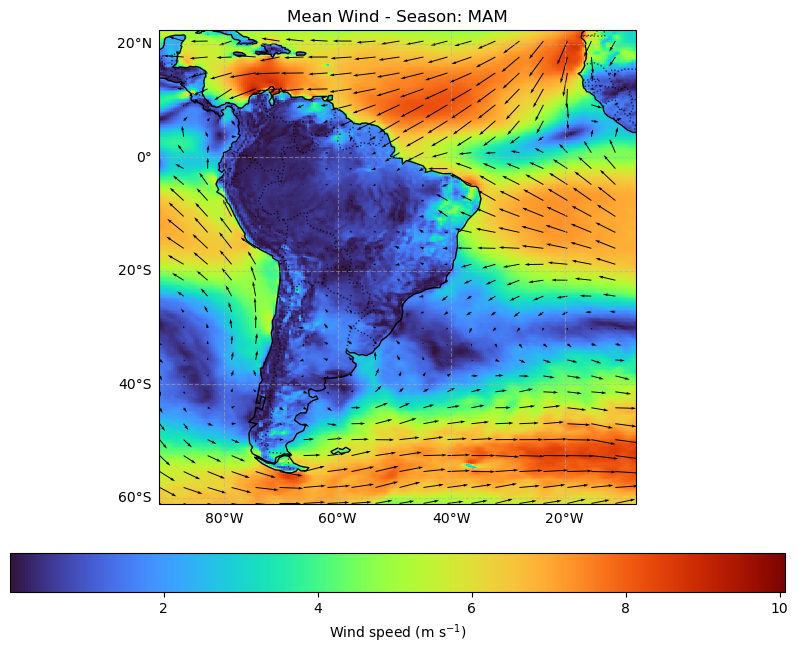

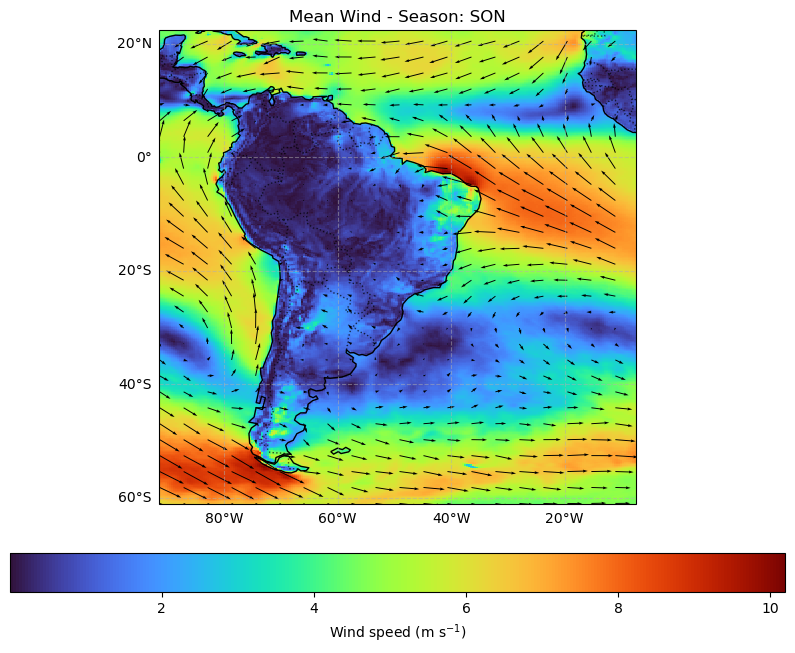

In [30]:
def plot_seasonal_winds(u, v):
    # 1. Group data by season and compute the mean for each group
    # This creates a new dimension called 'season'
    u_seasonal = u.groupby('time.season').mean('time')
    v_seasonal = v.groupby('time.season').mean('time')
    
    # 2. Get the list of seasons (DJF, JJA, etc.)
    seasons = u_seasonal.season.values

    for season in seasons:
        # Extract the specific season slice
        u_mean = u_seasonal.sel(season=season)
        v_mean = v_seasonal.sel(season=season)
        
        # Calculate wind speed
        wind_speed = np.sqrt(u_mean**2 + v_mean**2)

        # 3. Setup the Map
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # 4. Plot Background Speed
        im = wind_speed.plot(
            ax=ax, x='lon', y='lat',
            transform=ccrs.PlateCarree(),
            cmap='turbo',
            add_colorbar=True,
            cbar_kwargs={'label': 'Wind speed (m s$^{-1}$)', 'orientation': 'horizontal', 'pad': 0.08}
        )

        # 5. Plot Quiver
        skip = 12 # Increased skip slightly for clarity
        lons = u_mean.lon[::skip]
        lats = u_mean.lat[::skip]
        u_vals = u_mean.values[::skip, ::skip]
        v_vals = v_mean.values[::skip, ::skip]

        ax.quiver(
            lons, lats, u_vals, v_vals,
            transform=ccrs.PlateCarree(),
            color='black', scale=150, width=0.002
        )

        # 6. Aesthetics
        ax.add_feature(cfeature.COASTLINE, linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7)
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        
        plt.title(f'Mean Wind - Season: {season}')
        plt.show()

# Run it on your subsampled data
plot_seasonal_winds(u, v)

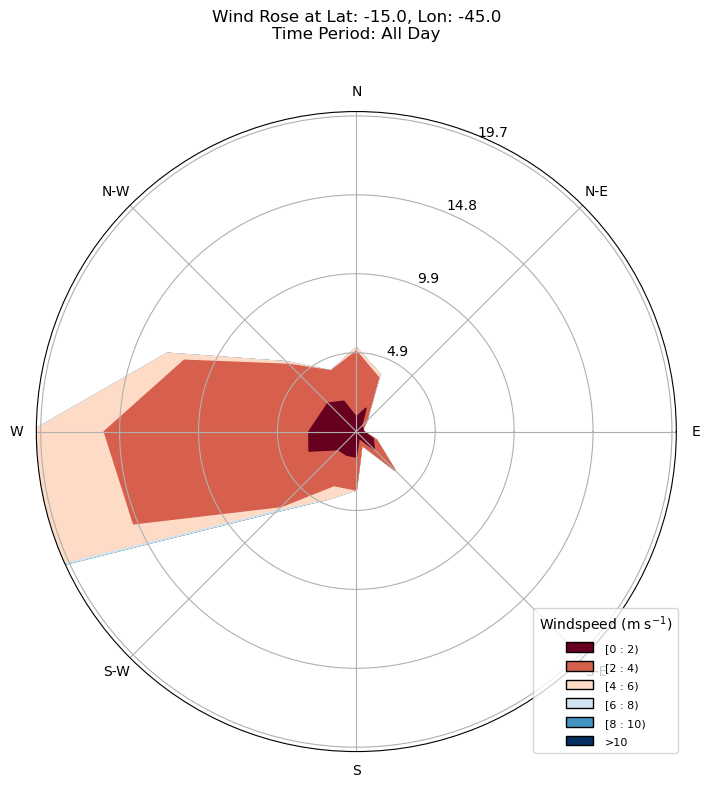

In [45]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

def plot_single_wind_rose(ds, lat_val, lon_val, level_idx=0, 
                          hour_range=None, bins=[0, 5, 10, 15, 20]):
    # 1. Select point and level
    point_ds = ds.sel(lat=lat_val, lon=lon_val, method='nearest')
    
    # Handle levels if the dimension exists
    if 'levels' in point_ds.dims:
        point_ds = point_ds.isel(levels=level_idx)
    
    # 2. Filter by Time of Day
    if hour_range is not None:
        point_ds = point_ds.where(
            (point_ds['time.hour'] >= hour_range[0]) & 
            (point_ds['time.hour'] <= hour_range[1]), 
            drop=True
        )

    # 3. Calculate Speed and Direction
    u = point_ds['x_wind']
    v = point_ds['y_wind']
    speed = np.sqrt(u**2 + v**2)
    direction = np.rad2deg(np.arctan2(u, v)) % 360
    
    # 4. Setup the Plot
    fig = plt.figure(figsize=(8, 8))
    ax = WindroseAxes.from_ax(fig=fig)
    
    '''
    # 5. Plot the Stacked Bar Chart
    ax.bar(direction.values, speed.values, 
           normed=True, 
           bins=bins, 
           opening=0.8, 
           edgecolor='white',
           cmap=plt.cm.RdBu)
    '''
    ax.contourf(direction.values, speed.values, 
                    normed=True, 
                    bins=bins, 
                    cmap=plt.cm.RdBu,
                    nsector=16) 
    
    
    # 6. Corrected Axis Constraints
    ax.set_rmax(20) # This fixes the frequency limit to 20%
    ax.set_legend(title="Windspeed (m s$^{-1}$)", loc='lower right', decimal_places=0)
    
    time_label = "All Day" if hour_range is None else f"Hours {hour_range[0]}-{hour_range[1]}"
    plt.title(f"Wind Rose at Lat: {lat_val}, Lon: {lon_val}\nTime Period: {time_label}", y=1.1)
    
    plt.show()

# Try running it again:
plot_single_wind_rose(ds_ready, lat_val=-15.0, lon_val=-45.0, bins=[0, 2, 4, 6, 8, 10])

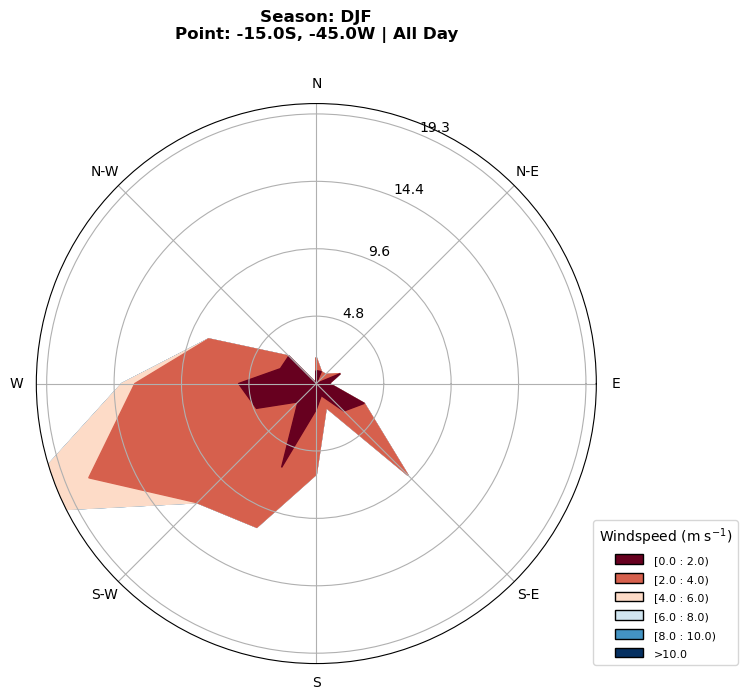

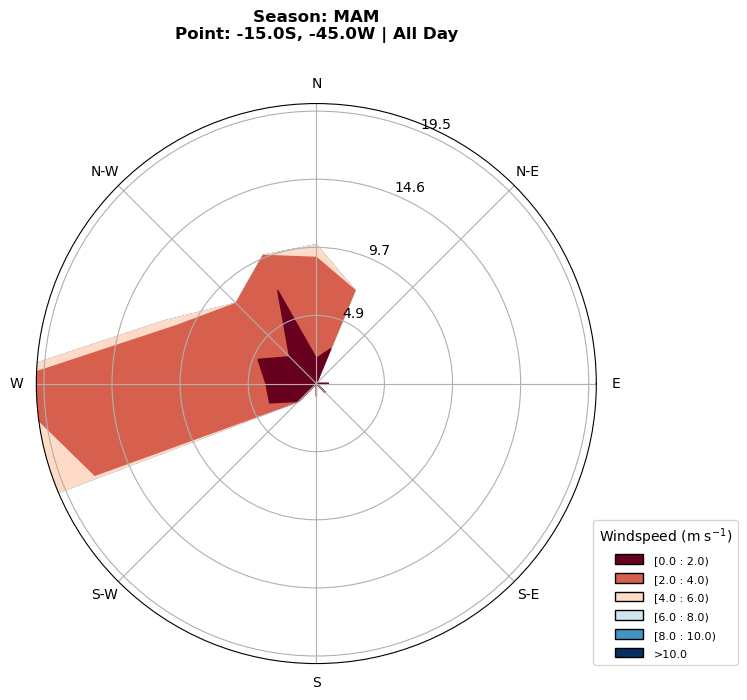

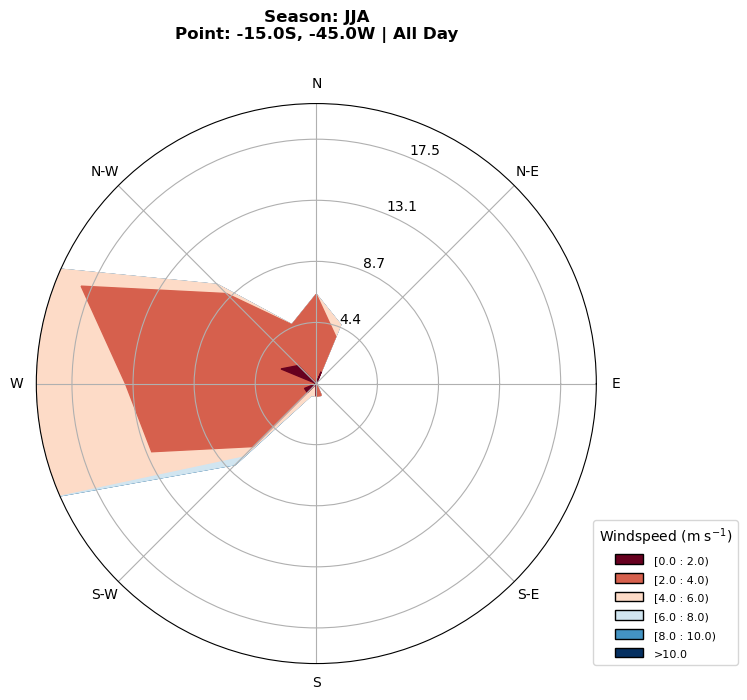

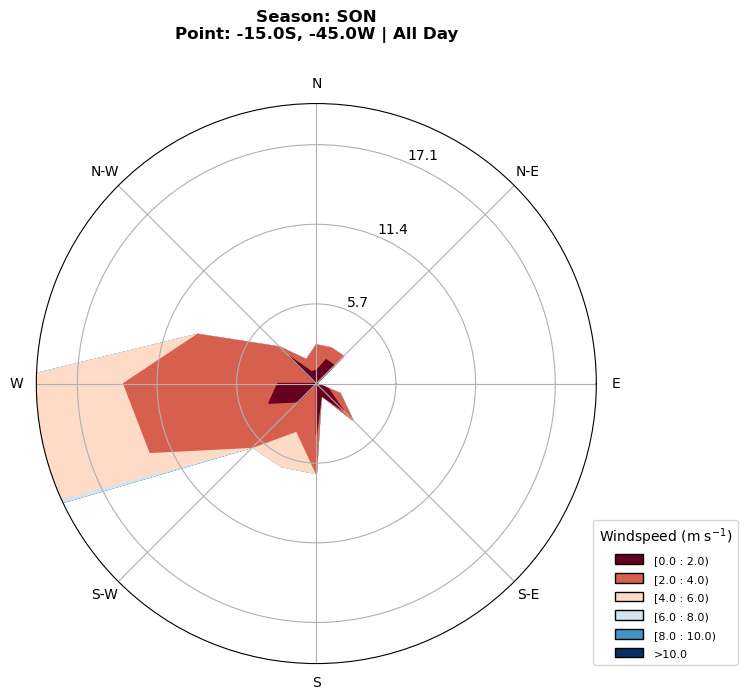

In [41]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

def plot_seasonal_roses_sequential(ds, lat, lon, level_idx=0, 
                                   hour_range=None, bins=[0, 2, 4, 6, 8, 10]):
    """
    Generates wind roses season-by-season using the RdBu colormap.
    """
    # 1. Selection Mode: Point vs Spatial Mean
    if isinstance(lat, (tuple, list)) and isinstance(lon, (tuple, list)):
        subset = ds.sel(lat=slice(lat[0], lat[1]), lon=slice(lon[0], lon[1]))
        data_ds = subset.mean(dim=['lat', 'lon'])
        location_label = f"Region: {lat}S, {lon}W"
    else:
        data_ds = ds.sel(lat=lat, lon=lon, method='nearest')
        location_label = f"Point: {lat}S, {lon}W"

    # 2. Select Level and Time Filter
    if 'levels' in data_ds.dims:
        data_ds = data_ds.isel(levels=level_idx)
    
    if hour_range is not None:
        data_ds = data_ds.where(
            (data_ds['time.hour'] >= hour_range[0]) & 
            (data_ds['time.hour'] <= hour_range[1]), 
            drop=True
        )

    # 3. Loop through seasons and create individual plots
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    
    for season in seasons:
        # Filter for the specific season
        seasonal_slice = data_ds.where(data_ds['time.season'] == season, drop=True)
        
        if len(seasonal_slice.time) == 0:
            print(f"No data found for season: {season}")
            continue
            
        # Calculate Speed and Direction
        u, v = seasonal_slice['x_wind'], seasonal_slice['y_wind']
        speed = np.sqrt(u**2 + v**2)
        direction = np.rad2deg(np.arctan2(u, v)) % 360

        # Create a new figure for each season
        fig = plt.figure(figsize=(7, 7))
        ax = WindroseAxes.from_ax(fig=fig)
        '''
        # 4. Plot using the previous cmap=plt.cm.RdBu
        ax.bar(direction.values, speed.values, 
               normed=True, 
               bins=bins, 
               opening=0.8, 
               edgecolor='white', # Set back to white as per your previous version
               cmap=plt.cm.RdBu) 
        '''
        ax.contourf(direction.values, speed.values, 
                    normed=True, 
                    bins=bins, 
                    cmap=plt.cm.RdBu,
                    nsector=16) 
        
        # 5. Fixed Axis Constraints for consistency
        ax.set_rmax(20) # Keep the 20% limit for consistent scaling
        
        # Labels and Title
        time_label = "All Day" if hour_range is None else f"Hours {hour_range[0]}-{hour_range[1]}"
        plt.title(f"Season: {season}\n{location_label} | {time_label}", y=1.1, fontweight='bold')
        
        ax.set_legend(title="Windspeed (m s$^{-1}$)", loc='lower right', bbox_to_anchor=(1.25, 0))
        
        plt.show()

# --- Run the function ---
my_bins = [0, 2, 4, 6, 8, 10]
plot_seasonal_roses_sequential(ds_ready, lat=-15.0, lon=-45.0, bins=my_bins)

# OLD CODE

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from windrose import WindroseAxes


def wind_rose_info(
    ds,
    u_var="x_wind",
    v_var="y_wind",
    lat=None,
    lon=None,
    level_index=0,
    spatial_mean=False,
    speed_bins=(0, 2, 4, 6, 8, 10, 15),
    figsize=(10, 10),

    # --- NEW OPTIONS ---
    show_counts=True,
    show_total=True,
    as_percent=True,
    print_table=False
):
    """
    Plot seasonal wind rose with optional counts + statistics.
    """

    # -----------------------------
    # Select wind components
    # -----------------------------
    u = ds[u_var]
    v = ds[v_var]

    # Vertical selection
    if "levels" in u.dims:
        u = u.isel(levels=level_index)
        v = v.isel(levels=level_index)

    # Spatial selection
    if spatial_mean:
        u = u.mean(dim=["lat", "lon"])
        v = v.mean(dim=["lat", "lon"])
        location_str = "Spatial mean"
    else:
        if lat is None or lon is None:
            raise ValueError("lat and lon must be provided if spatial_mean=False")

        u = u.sel(lat=lat, lon=lon, method="nearest")
        v = v.sel(lat=lat, lon=lon, method="nearest")

        location_str = f"lat={float(u.lat.values):.2f}, lon={float(u.lon.values):.2f}"

    # -----------------------------
    # Wind speed & direction
    # -----------------------------
    speed = np.sqrt(u**2 + v**2)
    direction = (270 - np.degrees(np.arctan2(v, u))) % 360

    spd = speed.load().values
    direc = direction.load().values

    # -----------------------------
    # Plot
    # -----------------------------
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="windrose")

    ax.bar(
        direc,
        spd,
        bins=speed_bins,
        normed=as_percent,
        opening=0.8,
        edgecolor="white",
    )

    ax.set_title(f"Wind rose ({location_str})")

    # -----------------------------
    # Extract histogram info
    # -----------------------------
    counts = ax._info["table"]
    bins = ax._info["bins"]
    N = len(spd)

    # -----------------------------
    # Legend with counts
    # -----------------------------
    legend = ax.legend(title="Wind speed (m/s)")

    if show_counts:
        totals = counts.sum(axis=1)
        for txt, c in zip(legend.texts, totals):
            txt.set_text(f"{txt.get_text()} ({int(c)})")

    # -----------------------------
    # Show total N
    # -----------------------------
    if show_total:
        ax.text(
            0.98,
            0.02,
            f"N = {N}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=10
        )

    # -----------------------------
    # Print table if requested
    # -----------------------------
    if print_table:
        print("\nCounts table (rows = speed bins, cols = directions):")
        print(counts)

    plt.tight_layout()
    return fig

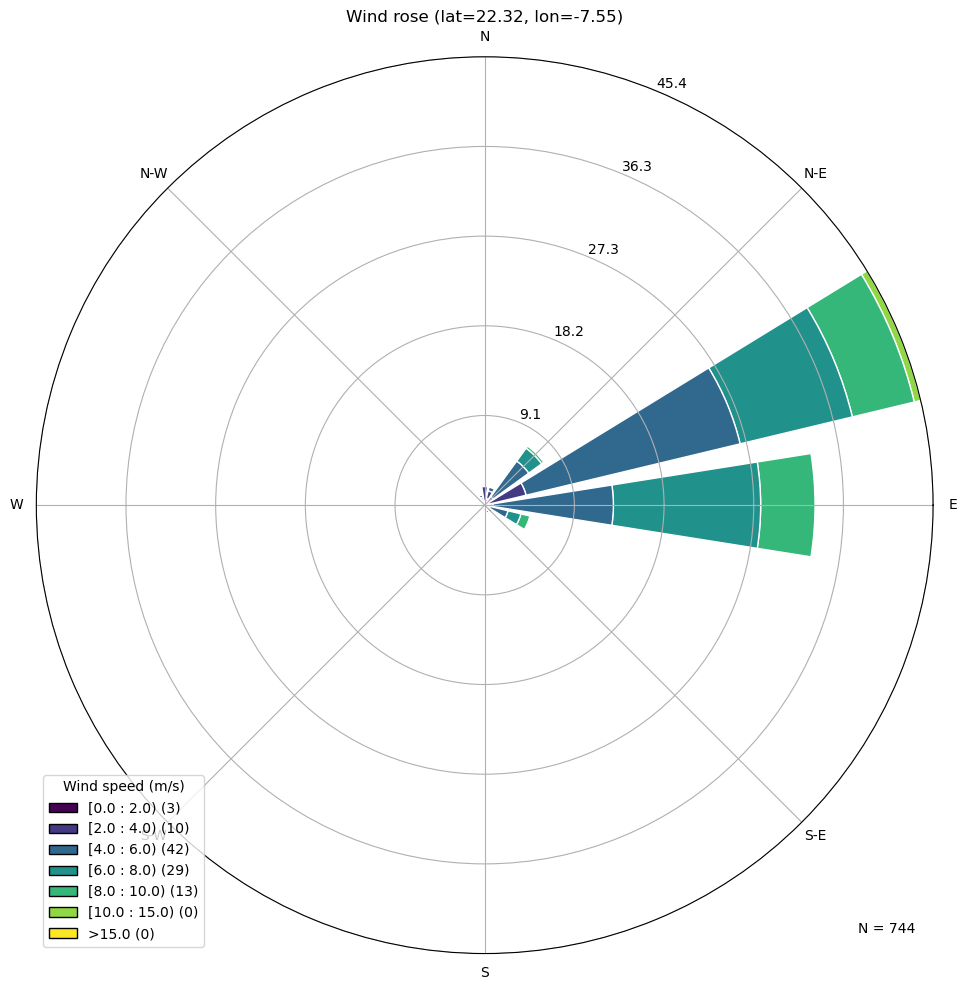

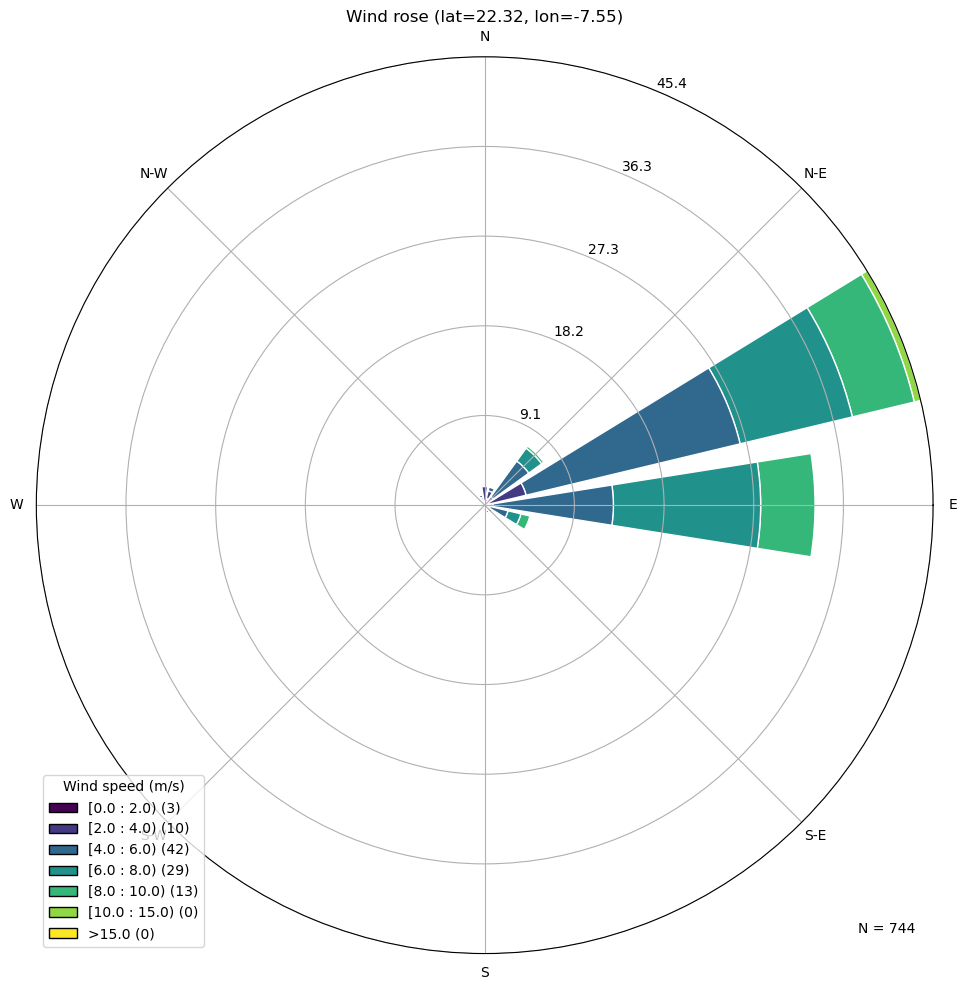

In [ ]:
wind_rose_info(
    ds,
    lat=52,
    lon=0,
    as_percent=True,
    show_counts=True,
    show_total=True
)

In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from windrose import WindroseAxes


def wind_rose(
    ds,
    u_var="x_wind",
    v_var="y_wind",
    lat=None,
    lon=None,
    level_index=0,
    spatial_mean=False,
    speed_bins=(0, 2, 4, 6, 8, 10, 15),
    figsize=(10, 10),
):
    """
    Plot seasonal wind roses (DJF, MAM, JJA, SON) from an xarray Dataset.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing wind components.
    u_var, v_var : str
        Names of zonal and meridional wind variables.
    lat, lon : float, optional
        Location for point extraction (nearest grid point).
        Ignored if spatial_mean=True.
    level_index : int
        Vertical level index to select.
    spatial_mean : bool
        If True, average over lat/lon before plotting.
    speed_bins : tuple
        Wind speed bins for wind rose.
    figsize : tuple
        Figure size.

    Returns
    -------
    matplotlib.figure.Figure
    """

    # -----------------------------
    # Select wind components
    # -----------------------------
    u = ds[u_var]
    v = ds[v_var]

    # Vertical selection
    if "levels" in u.dims:
        u = u.isel(levels=level_index)
        v = v.isel(levels=level_index)

    # Spatial selection
    if spatial_mean:
        u = u.mean(dim=["lat", "lon"])
        v = v.mean(dim=["lat", "lon"])
        location_str = "Spatial mean"
    else:
        if lat is None or lon is None:
            raise ValueError("lat and lon must be provided if spatial_mean=False")
        # Nawid - chooses specific lat and lon and get the wind for those values
        u = u.sel(lat=lat, lon=lon, method="nearest")
        v = v.sel(lat=lat, lon=lon, method="nearest")
        #N Nawid.- show the lat and the lon values used
        location_str = f"lat={float(u.lat.values):.2f}, lon={float(u.lon.values):.2f}"

    # -----------------------------
    # Wind speed & direction
    # -----------------------------
    speed = np.sqrt(u**2 + v**2)

    # Meteorological convention: direction wind is coming FROM
    direction = (270 - np.degrees(np.arctan2(v, u))) % 360

    wind = xr.Dataset(
        {
            "speed": speed,
            "direction": direction,
        }
    )

    # -----------------------------
    # Plot seasonal wind roses
    # -----------------------------
    fig = plt.figure(figsize=figsize)

    ax = fig.add_subplot(111, projection="windrose")

    spd = wind["speed"].load().values    
    direc = wind["direction"].load().values

    ax.bar(
    direc,
    spd,
    bins=speed_bins,
    normed=True,
    opening=0.8,
    edgecolor="white",
    )
    # Feature	Encodes
    #Angle	Direction
    #Radius	Frequency
    #Color	Speed

    ax.set_title(f"Wind rose ({location_str})")
    ax.legend(title="Wind speed (m/s)")

    plt.tight_layout()
    return None 


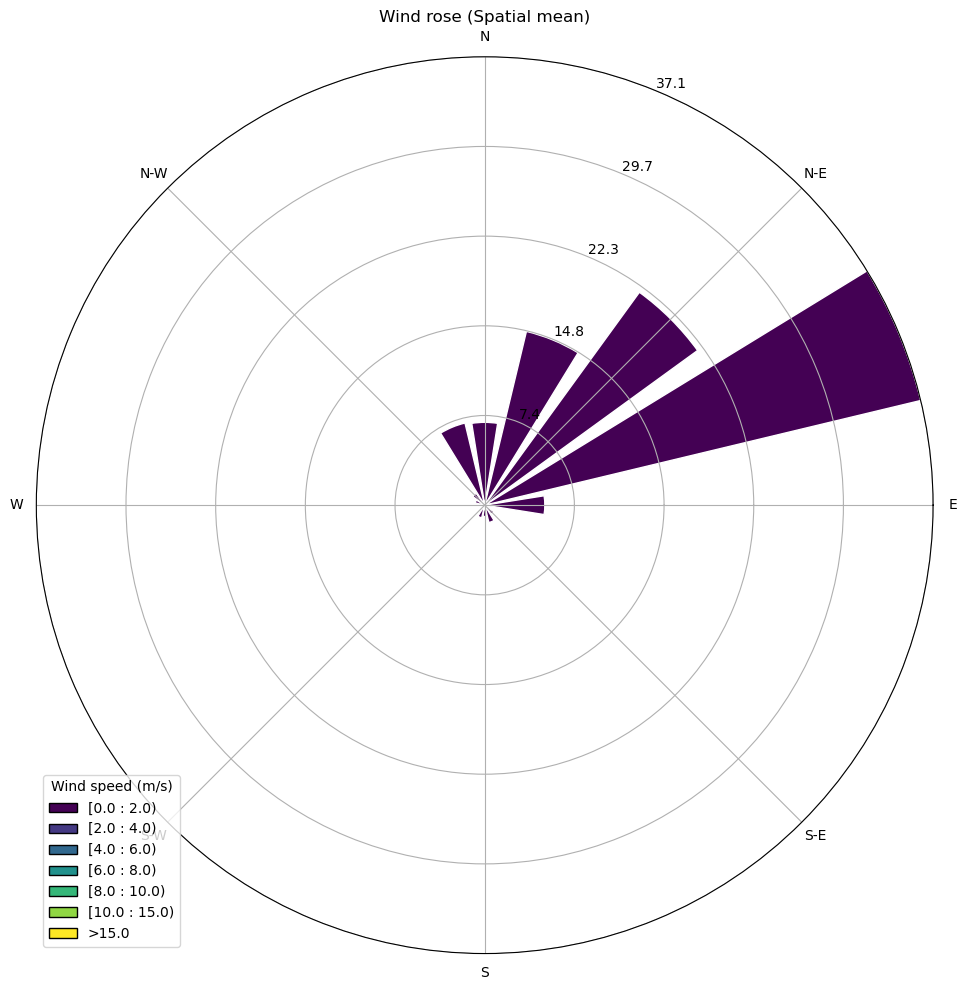

In [13]:
wind_rose(
    ds,
    spatial_mean=True,
    level_index=0
)

In [14]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from windrose import WindroseAxes


def seasonal_wind_rose(
    ds,
    u_var="x_wind",
    v_var="y_wind",
    lat=None,
    lon=None,
    level_index=0,
    spatial_mean=False,
    speed_bins=(0, 2, 4, 6, 8, 10, 15),
    figsize=(10, 10),
):
    """
    Plot seasonal wind roses (DJF, MAM, JJA, SON) from an xarray Dataset.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing wind components.
    u_var, v_var : str
        Names of zonal and meridional wind variables.
    lat, lon : float, optional
        Location for point extraction (nearest grid point).
        Ignored if spatial_mean=True.
    level_index : int
        Vertical level index to select.
    spatial_mean : bool
        If True, average over lat/lon before plotting.
    speed_bins : tuple
        Wind speed bins for wind rose.
    figsize : tuple
        Figure size.

    Returns
    -------
    matplotlib.figure.Figure
    """

    # -----------------------------
    # Select wind components
    # -----------------------------
    u = ds[u_var]
    v = ds[v_var]

    # Vertical selection
    if "levels" in u.dims:
        u = u.isel(levels=level_index)
        v = v.isel(levels=level_index)

    # Spatial selection
    if spatial_mean:
        u = u.mean(dim=["lat", "lon"])
        v = v.mean(dim=["lat", "lon"])
        location_str = "Spatial mean"
    else:
        if lat is None or lon is None:
            raise ValueError("lat and lon must be provided if spatial_mean=False")
        # Nawid - chooses specific lat and lon and get the wind for those values
        u = u.sel(lat=lat, lon=lon, method="nearest")
        v = v.sel(lat=lat, lon=lon, method="nearest")
        #N Nawid.- show the lat and the lon values used
        location_str = f"lat={float(u.lat.values):.2f}, lon={float(u.lon.values):.2f}"

    # -----------------------------
    # Wind speed & direction
    # -----------------------------
    speed = np.sqrt(u**2 + v**2)

    # Meteorological convention: direction wind is coming FROM
    direction = (270 - np.degrees(np.arctan2(v, u))) % 360

    wind = xr.Dataset(
        {
            "speed": speed,
            "direction": direction,
        }
    )

    # -----------------------------
    # Plot seasonal wind roses
    # -----------------------------
    seasons = ["DJF", "MAM", "JJA", "SON"]
    fig = plt.figure(figsize=figsize)

    for i, season in enumerate(seasons, 1):
        ax = fig.add_subplot(2, 2, i, projection="windrose")

        # Boolean mask avoids xarray GroupBy pitfalls
        # Nawid - this creates a boolean array to see whether each point belongs to the season of interest or not
        season_mask = wind.time.dt.season == season

        # Nawid - get the values for a particualr seaspm, turns the other values to nans ans then drops it
        spd = wind["speed"].where(season_mask, drop=True).compute().values
        direc = wind["direction"].where(season_mask, drop=True).compute().values

        ax.bar(
            direc,
            spd,
            bins=speed_bins,
            normed=True,
            opening=0.8,
            edgecolor="white",
        )

        ax.set_title(season)
        

    fig.suptitle(f"Seasonal wind roses ({location_str})", y=1.02)
    fig.legend(title="Wind speed (m/s)")
    
    plt.tight_layout()

    return fig

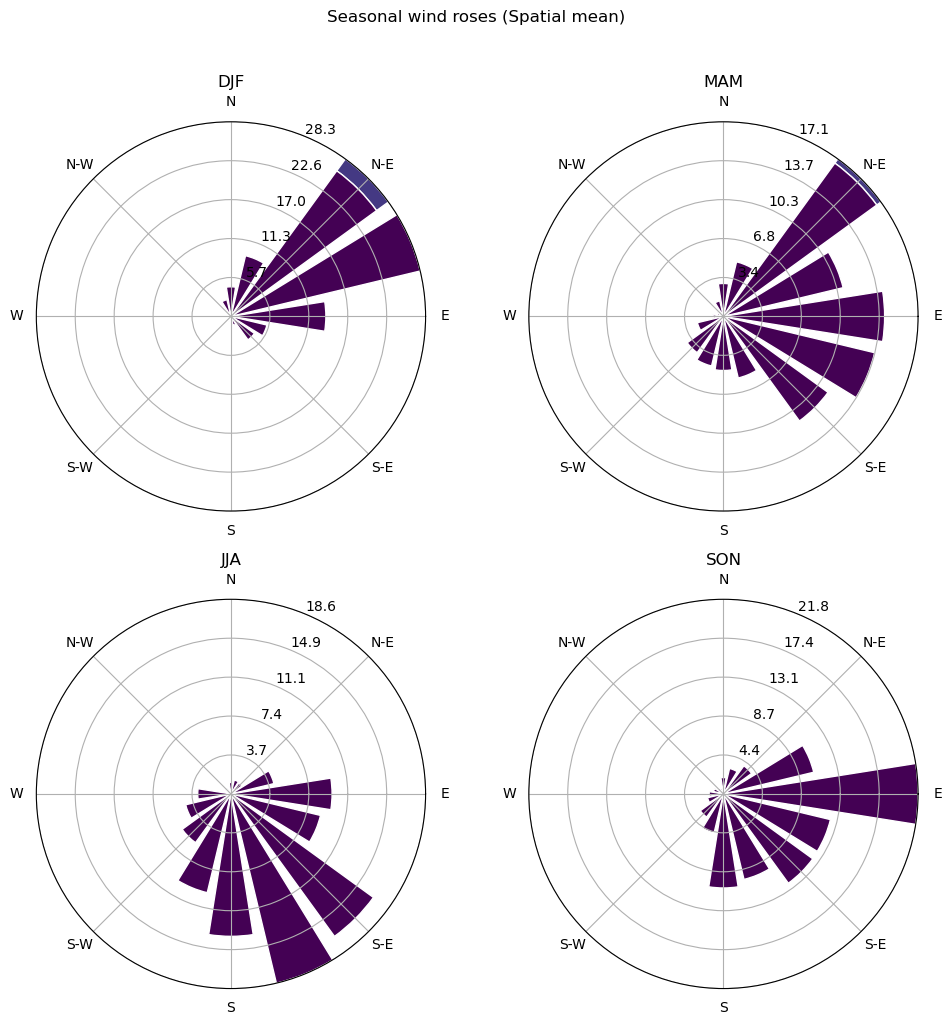

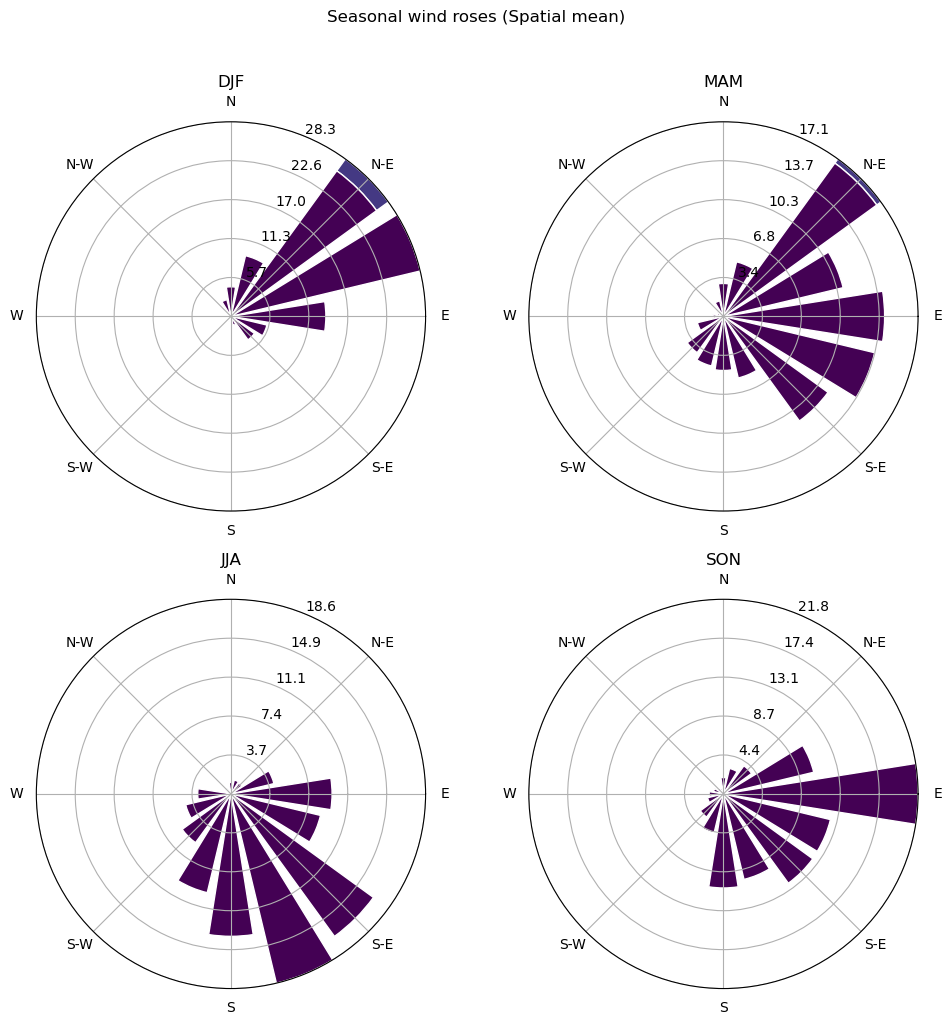

In [22]:
seasonal_wind_rose(
    ds,
    spatial_mean=True,
    level_index=0
)

### 

In [7]:
ds

<xarray.Dataset>
Dimensions:                              (lat: 357, levels: 20, lon: 239,
                                          time: 8760)
Coordinates:
  * lat                                  (lat) float64 -60.98 -60.75 ... 22.32
    sigma                                (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * levels                               (levels) int32 1 3 6 9 ... 48 51 54 57
    level_height                         (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * lon                                  (lon) float64 -91.33 -90.98 ... -7.553
  * time                                 (time) datetime64[ns] 2016-01-01 ......
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 dask.array<chunksize=(357, 120, 500), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 10, 500), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

In [23]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


def wind_quiver(
    ds,
    u_var="x_wind",
    v_var="y_wind",
    level_index=0,
    vertical_mean=False,
    height_range=None,
    stride=10,
    cmap="viridis",
    figsize=(10, 8),
    reference_speed=10,  # m/s, for arrow length legend
    key_pos=(0.1, 0.1),  # X, Y position in axis fraction (0-1)
):
    """
    Plot annual mean wind quiver map with arrow length legend and colorbar.
    Arrows show mean wind vector; colour shows wind speed.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing wind fields.
    u_var, v_var : str
        Variable names for zonal and meridional wind.
    level_index : int
        Level to use if not vertically averaging.
    vertical_mean : bool
        If True, average over all levels.
    height_range : tuple (min_h, max_h), optional
        Average only levels within height range.
    stride : int
        Spatial thinning factor (reduces arrow density).
    cmap : str
        Colormap for wind speed.
    figsize : tuple
        Figure size.
    reference_speed : float
        Speed (m/s) for quiver key legend arrow.
    key_pos : tuple
        (X, Y) position of quiver key in axis fraction (0-1).
    """

    # ----------------------------
    # Select wind variables
    # ----------------------------
    u = ds[u_var]
    v = ds[v_var]

    # ----------------------------
    # Vertical handling
    # ----------------------------
    if "levels" in u.dims:
        if height_range is not None:
            zmin, zmax = height_range
            mask = (ds.level_height >= zmin) & (ds.level_height <= zmax)
            u = u.where(mask, drop=True).mean("levels")
            v = v.where(mask, drop=True).mean("levels")
        elif vertical_mean:
            u = u.mean("levels")
            v = v.mean("levels")
        else:
            u = u.isel(levels=level_index)
            v = v.isel(levels=level_index)

    # ----------------------------
    # Time mean
    # ----------------------------
    u_mean = u.mean("time")
    v_mean = v.mean("time")

    # ----------------------------
    # Speed magnitude
    # ----------------------------
    speed = np.sqrt(u_mean**2 + v_mean**2)

    # ----------------------------
    # Spatial thinning
    # ----------------------------
    u_plot = u_mean.isel(
        lat=slice(None, None, stride),
        lon=slice(None, None, stride)
    ).compute()

    v_plot = v_mean.isel(
        lat=slice(None, None, stride),
        lon=slice(None, None, stride)
    ).compute()

    speed_plot = speed.isel(
        lat=slice(None, None, stride),
        lon=slice(None, None, stride)
    ).compute()

    # ----------------------------
    # Meshgrid for quiver
    # ----------------------------
    lon2d, lat2d = np.meshgrid(
        u_plot.lon.values,
        u_plot.lat.values
    )

    # ----------------------------
    # Plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=figsize)

    q = ax.quiver(
        lon2d,
        lat2d,
        u_plot.values,
        v_plot.values,
        speed_plot.values,
        cmap=cmap,
        scale=None
    )

    # Axis labels
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Optional: prevent map distortion
    ax.set_aspect("auto")

    # ----------------------------
    # Colorbar for speed (color)
    # ----------------------------
    cbar = fig.colorbar(q, ax=ax, orientation="vertical", pad=0.02)
    cbar.set_label("Wind speed (m/s)")
    '''
    # ----------------------------
    # Quiver key for arrow length (size)
    # ----------------------------
    ax.quiverkey(
        q,
        X=key_pos[0],
        Y=key_pos[1],
        U=reference_speed,
        label=f"{reference_speed} m/s",
        labelpos="E",
        coordinates="axes",
        color="k"
    )
    '''
    
    plt.tight_layout()
    return fig



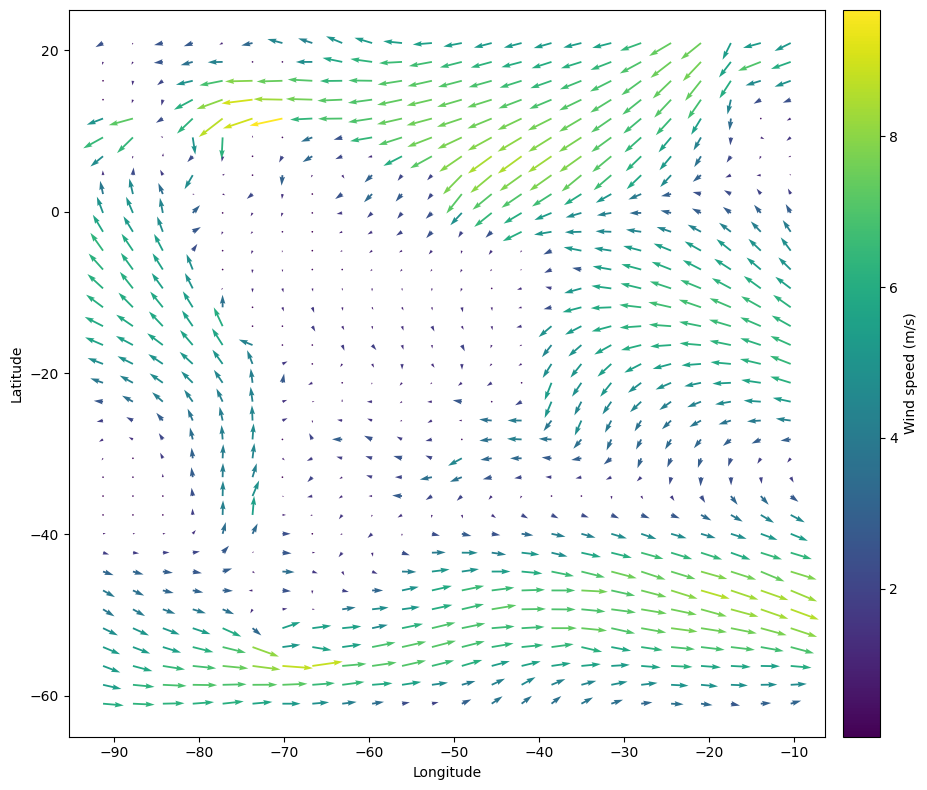

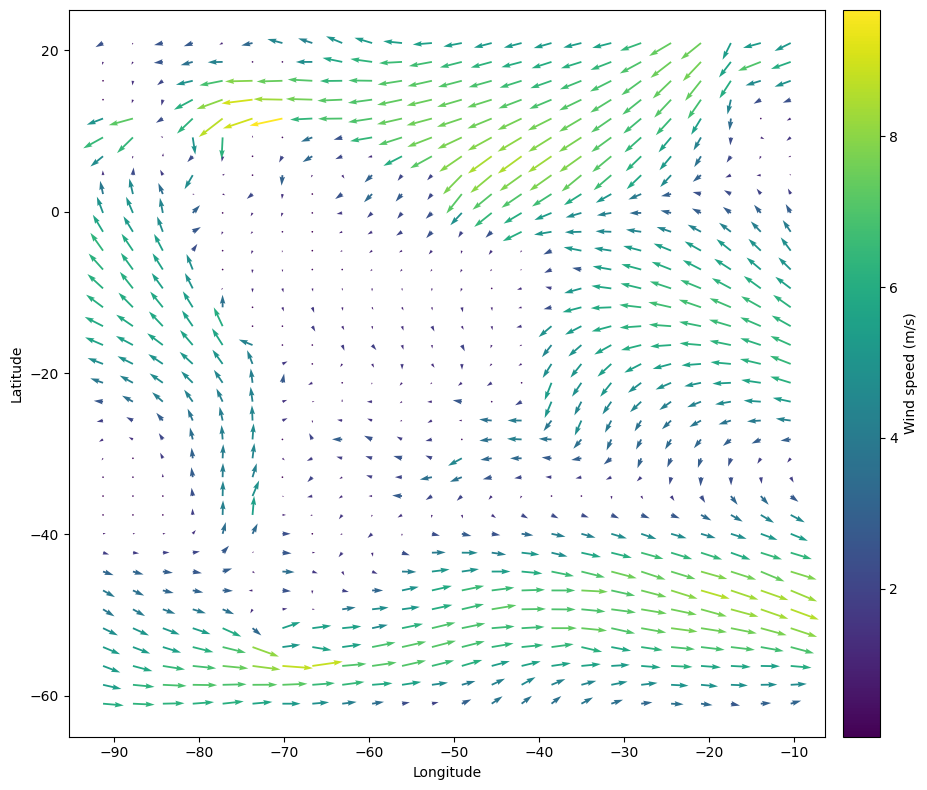

In [24]:
wind_quiver(ds, level_index=0)


In [30]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def wind_quiver_map(
    ds,
    u_var="x_wind",
    v_var="y_wind",
    level_index=0,
    vertical_mean=False,
    height_range=None,
    stride=10,
    cmap="viridis",
    figsize=(12, 8),
    reference_speed=10,
    key_pos=(0.1, 0.1),
    projection=ccrs.PlateCarree()  # default geographic projection
):
    """
    Plot wind vectors projected on a map with color representing speed.
    """

    # ----------------------------
    # Select wind variables
    # ----------------------------
    u = ds[u_var]
    v = ds[v_var]

    # ----------------------------
    # Vertical handling
    # ----------------------------
    if "levels" in u.dims:
        if height_range is not None:
            zmin, zmax = height_range
            mask = (ds.level_height >= zmin) & (ds.level_height <= zmax)
            u = u.where(mask, drop=True).mean("levels")
            v = v.where(mask, drop=True).mean("levels")
        elif vertical_mean:
            u = u.mean("levels")
            v = v.mean("levels")
        else:
            u = u.isel(levels=level_index)
            v = v.isel(levels=level_index)

    # ----------------------------
    # Time mean
    # ----------------------------
    u_mean = u.mean("time")
    v_mean = v.mean("time")

    # ----------------------------
    # Speed magnitude
    # ----------------------------
    speed = np.sqrt(u_mean**2 + v_mean**2)

    # ----------------------------
    # Spatial thinning
    # ----------------------------
    u_plot = u_mean.isel(
        lat=slice(None, None, stride),
        lon=slice(None, None, stride)
    ).compute()
    v_plot = v_mean.isel(
        lat=slice(None, None, stride),
        lon=slice(None, None, stride)
    ).compute()
    speed_plot = speed.isel(
        lat=slice(None, None, stride),
        lon=slice(None, None, stride)
    ).compute()

    # ----------------------------
    # Meshgrid for quiver
    # ----------------------------
    lon2d, lat2d = np.meshgrid(
        u_plot.lon.values,
        u_plot.lat.values
    )

    # ----------------------------
    # Plot with map projection
    # ----------------------------
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': projection})

    # Add map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

    # Quiver plot
    q = ax.quiver(
        lon2d,
        lat2d,
        u_plot.values,
        v_plot.values,
        speed_plot.values,
        cmap=cmap,
        scale=None,
        transform=ccrs.PlateCarree()  # data is in lat/lon
    )

    # Colorbar
    cbar = fig.colorbar(q, ax=ax, orientation="vertical", pad=0.02)
    cbar.set_label("Wind speed (m/s)")

    # Optional: add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    plt.tight_layout()
    return fig


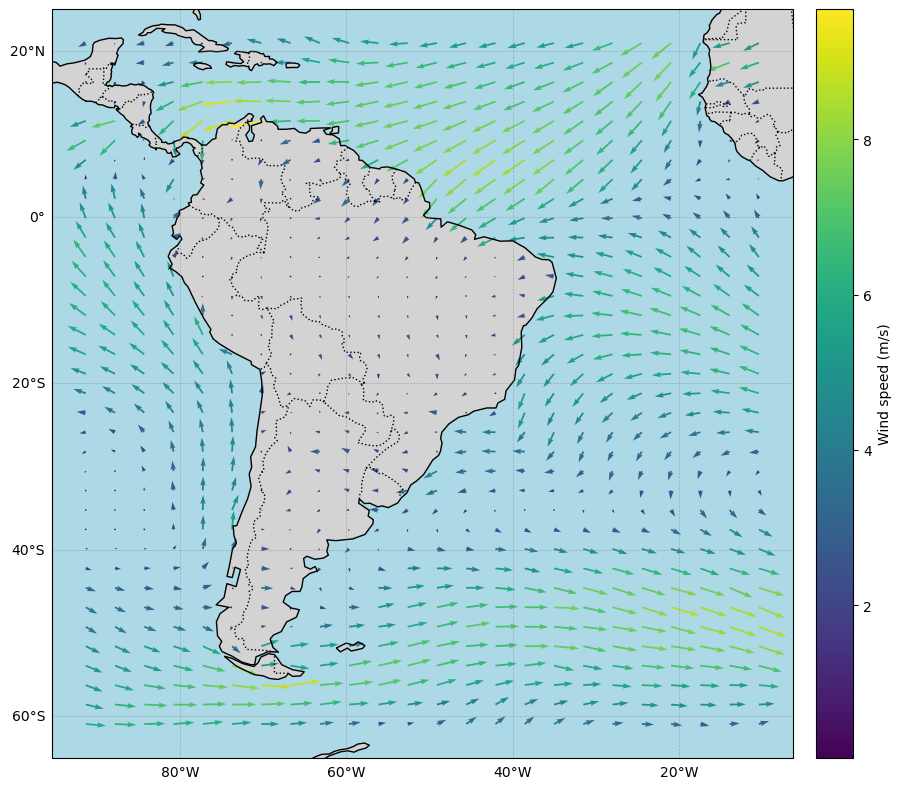

In [31]:
import cartopy.crs as ccrs

# Default PlateCarree projection (lat/lon)
fig = wind_quiver_map(ds)